In [1]:
# ablacion: sin features con F1 individual > 0.9 (leakage, umbral 0.9). NSL-KDD sin src_bytes/dst_bytes, Mirai sin avg_pkt_size, DS2OS sin cambios
import os as _os
_os.makedirs(str(Path.cwd().parent / "figuras_sinleak"), exist_ok=True)
_os.chdir(str(Path.cwd().parent / "figuras_sinleak"))
print('Salidas relativas (figuras/JSON-relativos) -> C:/Users/user/TFM/figuras_sinleak')

# imports y configuración global

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

# Preprocesamiento — MISMO pipeline que réplicas anteriores
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Modelo principal
from sklearn.ensemble import RandomForestClassifier

# Métricas — MISMAS que réplicas anteriores
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score,
    precision_score, recall_score
)

# SHAP — explicabilidad post-hoc
import shap

# Visualización
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size']  = 10

# Semilla global — igual que TODAS las réplicas del TFM
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# hiperparametros RF: Khare & Totaro no especifican n_estimators/max_depth, se usa n=100 + class_weight balanced (R2L/U2R)
RF_PARAMS = dict(
    n_estimators = 100,        # número de árboles (estándar literatura 2020)
    class_weight = 'balanced', # mitiga desbalance de clases (R2L, U2R)
    random_state = RANDOM_SEED,
    n_jobs       = -1,         # paralelización total
)

# Función de evaluación — MISMA estructura que EBM.ipynb
def evaluar_modelo(y_true, y_pred, y_proba, nombre_dataset, nombres_clases=None):
    """Calcula y muestra métricas idénticas a las réplicas anteriores."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # AUC-ROC multiclase: OvR (One-vs-Rest), igual que EBM.ipynb
    n_clases = y_proba.shape[1] if y_proba.ndim > 1 else 2
    if n_clases == 2:
        auc = roc_auc_score(y_true, y_proba[:, 1])
    else:
        auc = roc_auc_score(
            y_true, y_proba,
            multi_class='ovr', average='macro'
        )

    print(f'============================================================')
    print(f'  RF+SHAP — {nombre_dataset:<40}')
    print(f'============================================================')
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  Precision  : {prec:.4f}  (macro)')
    print(f'  Recall     : {rec:.4f}  (macro)')
    print(f'  F1-Score   : {f1:.4f}  (macro)')
    print(f'  AUC-ROC    : {auc:.4f}')
    print(f'------------------------------------------------------------')
    print(classification_report(y_true, y_pred,
                                target_names=nombres_clases,
                                zero_division=0))
    return {'dataset': nombre_dataset, 'acc': acc, 'prec': prec,
            'rec': rec, 'f1': f1, 'auc': auc}

print('Librerías cargadas correctamente.')
print(f'Semilla global   : {RANDOM_SEED}')
print(f'Versión SHAP     : {shap.__version__}')
print(f'RF hiperparámetros: {RF_PARAMS}')


Salidas relativas (figuras/JSON-relativos) -> C:/Users/user/TFM/figuras_sinleak


Librerías cargadas correctamente.
Semilla global   : 42
Versión SHAP     : 0.49.1
RF hiperparámetros: {'n_estimators': 100, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}


---
## DATASET 1 — NSL-KDD


In [2]:
# mismo preprocesado que Clasificadores_NSL-KDD.ipynb (41 cols, 8 seleccionadas por IG>0.40, LabelEncoder, split 80/20 + MinMaxScaler)

COL_NAMES_NSL = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# 8 features con Information Gain > 0.40 (Aljawarneh 2018, Table 4)
SELECTED_FEATURES_NSL = [
    'service',                # feature 3
    'flag',                   # feature 4
    'diff_srv_rate',          # feature 30
    'same_srv_rate',          # feature 29
    'dst_host_srv_count',     # feature 33
    'dst_host_same_srv_rate', # feature 34
]

CLASS_NAMES_NSL = {1: 'Normal', 2: 'DoS', 3: 'Probe', 4: 'R2L', 5: 'U2R'}

DOS   = {'back','land','neptune','pod','smurf','teardrop',
         'apache2','udpstorm','processtable','mailbomb'}
PROBE = {'ipsweep','nmap','portsweep','satan','mscan','saint'}
R2L   = {'ftp_write','guess_passwd','imap','multihop','phf','spy',
         'warezclient','warezmaster','sendmail','named',
         'snmpgetattack','snmpguess','xlock','xsnoop','worm'}
U2R   = {'buffer_overflow','loadmodule','perl','rootkit',
         'httptunnel','ps','sqlattack','xterm'}

def map_label_nsl(label):
    label = label.lower().strip()
    if label == 'normal': return 1
    if label in DOS:      return 2
    if label in PROBE:    return 3
    if label in R2L:      return 4
    if label in U2R:      return 5
    return 2  # ataque no catalogado → DoS

def find_file_nsl(filename):
    search_paths = [
        (Path.home() / ".cache" / "kagglehub" / "datasets" / "hassan06" / "nslkdd" / "versions" / "1"),
        Path("."),
        Path.home() / "Downloads",
        Path.home() / "datasets",
        Path("/data"),
    ]
    for base in search_paths:
        candidate = base / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"No se encontró '{filename}'.\n"
        "Descárgalo de: https://www.kaggle.com/datasets/hassan06/nslkdd"
    )

# Carga
df_nsl = pd.read_csv(
    find_file_nsl('KDDTrain+_20Percent.txt'),
    header=None,
    names=COL_NAMES_NSL
).drop(columns=['difficulty'])

# Encoding nominal (idéntico a Clasificadores_NSL-KDD.ipynb)
protocol_map = {'tcp': 1, 'udp': 2, 'icmp': 3}
df_nsl['protocol_type'] = df_nsl['protocol_type'].str.lower().map(protocol_map).fillna(0)
le_service_nsl = LabelEncoder()
le_flag_nsl    = LabelEncoder()
df_nsl['service'] = le_service_nsl.fit_transform(df_nsl['service'].astype(str))
df_nsl['flag']    = le_flag_nsl.fit_transform(df_nsl['flag'].astype(str))

# Mapeo a 5 clases
df_nsl['label'] = df_nsl['label'].apply(map_label_nsl)

# Features y etiquetas
X_nsl = df_nsl[SELECTED_FEATURES_NSL].values
y_nsl = df_nsl['label'].values

# Split 80/20 estratificado (Aljawarneh 2018, Section 5)
X_tr_nsl, X_te_nsl, y_tr_nsl, y_te_nsl = train_test_split(
    X_nsl, y_nsl,
    test_size    = 0.20,
    random_state = RANDOM_SEED,
    stratify     = y_nsl
)

# Normalización MinMaxScaler post-split (sin data leakage)
scaler_nsl  = MinMaxScaler()
X_tr_nsl = scaler_nsl.fit_transform(X_tr_nsl)
X_te_nsl = scaler_nsl.transform(X_te_nsl)

CLASSES_NSL = sorted(np.unique(y_tr_nsl))  # [1, 2, 3, 4, 5]

print(f'NSL-KDD cargado: {len(df_nsl):,} instancias')
print(f'Train: {len(X_tr_nsl):,} | Test: {len(X_te_nsl):,}')
print(f'Features: {SELECTED_FEATURES_NSL}')
print(f'\nDistribución por clase:')
print(f'  {"Clase":<10} {"Train":>8}  {"Test":>6}')
print(f'  {"-"*10} {"-"*8}  {"-"*6}')
for c in CLASSES_NSL:
    print(f'  {CLASS_NAMES_NSL[c]:<10} {(y_tr_nsl==c).sum():>8,}  {(y_te_nsl==c).sum():>6,}')


NSL-KDD cargado: 25,192 instancias
Train: 20,153 | Test: 5,039
Features: ['service', 'flag', 'diff_srv_rate', 'same_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate']

Distribución por clase:
  Clase         Train    Test
  ---------- --------  ------
  Normal       10,759   2,690
  DoS           7,387   1,847
  Probe         1,831     458
  R2L             167      42
  U2R               9       2


In [3]:
# entrenamiento RF y metricas: mismos hiperparametros que Clasificadores_NSL-KDD.ipynb + class_weight='balanced' para R2L/U2R

rf_nsl = RandomForestClassifier(**RF_PARAMS)

print('Entrenando Random Forest en NSL-KDD...')
rf_nsl.fit(X_tr_nsl, y_tr_nsl)
print('Entrenamiento completado.')

y_pred_nsl  = rf_nsl.predict(X_te_nsl)
y_proba_nsl = rf_nsl.predict_proba(X_te_nsl)  # shape (n_samples, 5)

nombres_clases_nsl = [CLASS_NAMES_NSL[c] for c in rf_nsl.classes_]

res_nsl = evaluar_modelo(
    y_te_nsl, y_pred_nsl, y_proba_nsl,
    nombre_dataset  = 'NSL-KDD',
    nombres_clases  = nombres_clases_nsl
)


Entrenando Random Forest en NSL-KDD...


Entrenamiento completado.
  RF+SHAP — NSL-KDD                                 
  Accuracy   : 0.9704
  Precision  : 0.7601  (macro)
  Recall     : 0.8069  (macro)
  F1-Score   : 0.7703  (macro)
  AUC-ROC    : 0.9402
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      2690
         DoS       0.99      0.97      0.98      1847
       Probe       0.93      0.94      0.94       458
         R2L       0.71      0.64      0.68        42
         U2R       0.20      0.50      0.29         2

    accuracy                           0.97      5039
   macro avg       0.76      0.81      0.77      5039
weighted avg       0.97      0.97      0.97      5039



Calculando valores SHAP para NSL-KDD (puede tardar ~30s)...


Valores SHAP calculados. Formato: array 3D (2000, 6, 5) | Clases: 5


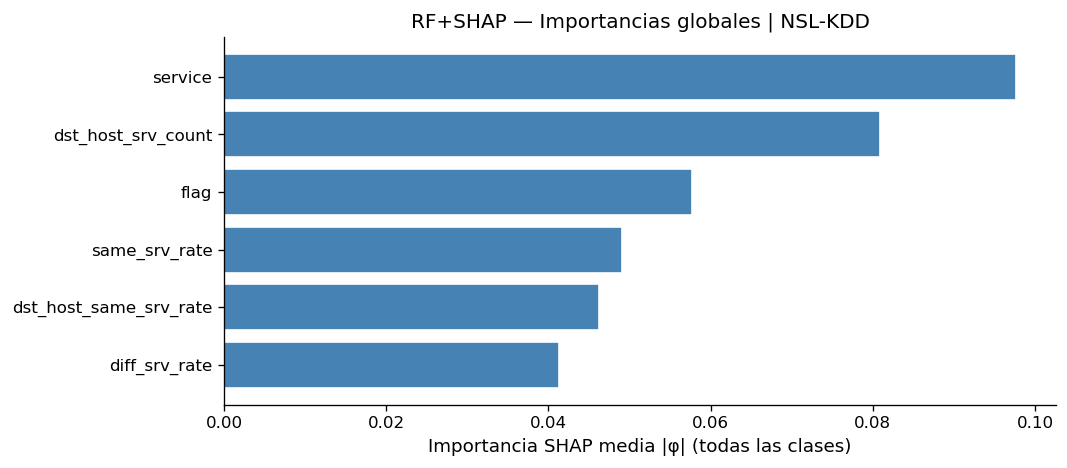

Figura guardada: rfshap_nslkdd_importancias_globales.png

Generando beeswarm SHAP para clase DoS (NSL-KDD)...


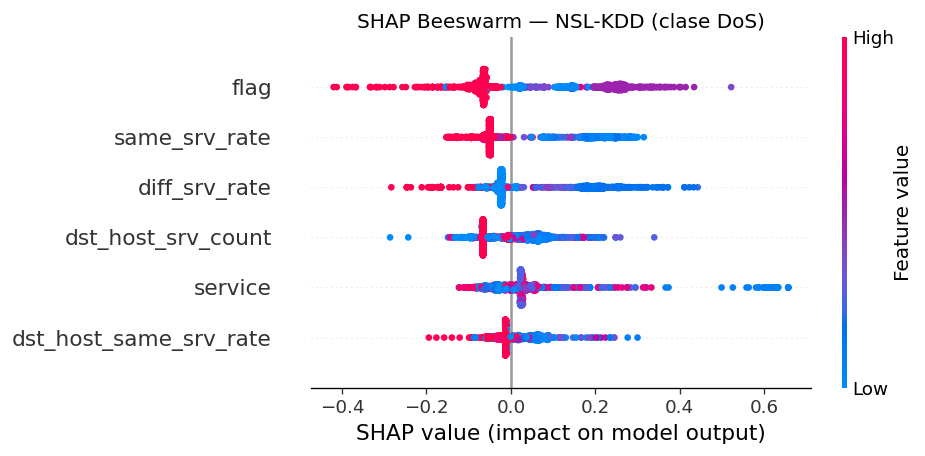

Figura guardada: rfshap_nslkdd_beeswarm_dos.png

Explicación local — muestra de ataque (NSL-KDD)
  Etiqueta real : DoS
  Predicción RF : DoS

Top contribuciones SHAP locales (clase predicha):
               feature  shap_value  feature_val
               service    0.563362     0.215385
dst_host_same_srv_rate    0.126369     0.960000
    dst_host_srv_count    0.123662     0.956693
                  flag   -0.037163     0.900000
         diff_srv_rate    0.013888     0.000000
         same_srv_rate   -0.012146     1.000000


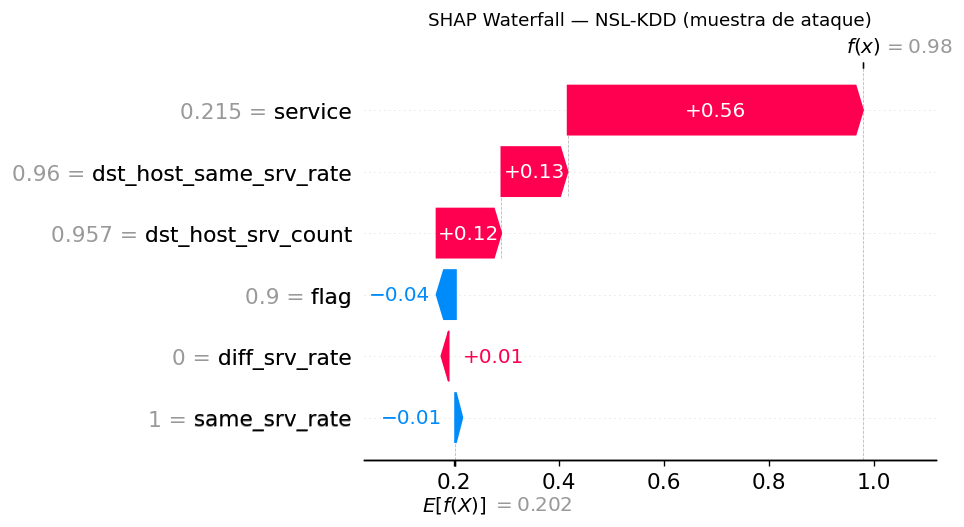

Figura guardada: rfshap_nslkdd_waterfall_local.png


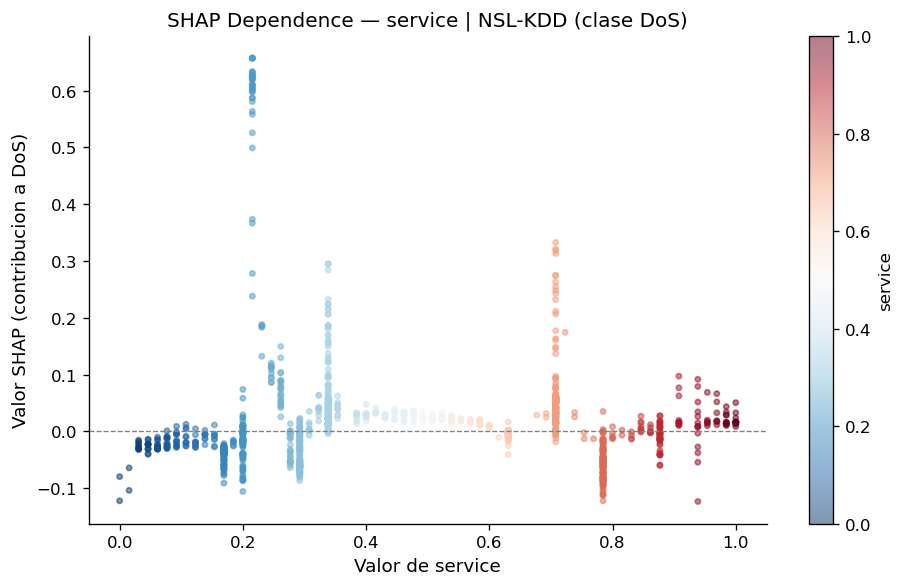

Figura guardada: rfshap_nslkdd_dependence_service.png


In [4]:
# SHAP (post-hoc) con TreeExplainer, exacto para arboles (vs KernelExplainer, aproximado y lento)
# multiclase: shap_values[clase][muestra, feature]; se analiza DoS (clase 1) y se suma |SHAP| para el resumen global

print('Calculando valores SHAP para NSL-KDD (puede tardar ~30s)...')

# TreeExplainer — exacto y eficiente para Random Forest
explainer_nsl = shap.TreeExplainer(rf_nsl)

# Submuestra para visualización
np.random.seed(RANDOM_SEED)
idx_sample = np.random.choice(len(X_te_nsl), size=min(2000, len(X_te_nsl)), replace=False)
X_sample_nsl = X_te_nsl[idx_sample]
y_sample_nsl = y_te_nsl[idx_sample]

# Detectar formato de salida de shap_values (API antigua vs nueva)
# SHAP < 0.40 : lista de arrays (n_muestras, n_features) — uno por clase
# SHAP >= 0.40: array 3D (n_muestras, n_features, n_clases)
# La función get_shap_for_class() normaliza ambos casos.
shap_raw_nsl = explainer_nsl.shap_values(X_sample_nsl)

def get_shap_for_class(shap_raw, clase_idx):
    """Extrae la matriz (n_muestras, n_features) para una clase concreta,
    independientemente de si shap_raw es lista o array 3D."""
    if isinstance(shap_raw, list):
        # API antigua: lista[clase_idx] → (n_muestras, n_features)
        return shap_raw[clase_idx]
    else:
        # API nueva: array 3D → slicing por última dimensión
        return shap_raw[..., clase_idx]

def get_all_classes_abs_mean(shap_raw):
    """Devuelve (n_muestras, n_features) con el |SHAP| medio sobre todas las clases."""
    if isinstance(shap_raw, list):
        n_clases = len(shap_raw)
        return np.mean([np.abs(shap_raw[c]) for c in range(n_clases)], axis=0)
    else:
        # array 3D: (n_muestras, n_features, n_clases)
        return np.abs(shap_raw).mean(axis=-1)  # → (n_muestras, n_features)

n_clases_nsl = len(rf_nsl.classes_)
formato = 'lista' if isinstance(shap_raw_nsl, list) else f'array 3D {shap_raw_nsl.shape}'
print(f'Valores SHAP calculados. Formato: {formato} | Clases: {n_clases_nsl}')

# Importancias globales (|SHAP| medio sobre todas las clases)
shap_abs_mean_nsl = get_all_classes_abs_mean(shap_raw_nsl)  # (n_muestras, n_features)
importancias_nsl  = shap_abs_mean_nsl.mean(axis=0)           # (n_features,)
idx_sorted_nsl    = np.argsort(importancias_nsl)[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(
    [SELECTED_FEATURES_NSL[i] for i in idx_sorted_nsl][::-1],
    [importancias_nsl[i]      for i in idx_sorted_nsl][::-1],
    color='steelblue', edgecolor='white'
)
ax.set_xlabel('Importancia SHAP media |φ| (todas las clases)', fontsize=11)
ax.set_title('RF+SHAP — Importancias globales | NSL-KDD', fontsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('rfshap_nslkdd_importancias_globales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: rfshap_nslkdd_importancias_globales.png')

# Beeswarm — clase DoS (índice 1 en rf_nsl.classes_)
# summary_plot necesita (n_muestras, n_features) para una sola clase
# Se usa la función normalizada get_shap_for_class() para evitar el AssertionError
print('\nGenerando beeswarm SHAP para clase DoS (NSL-KDD)...')
idx_dos = list(rf_nsl.classes_).index(2)  # clase DoS = 2 en el mapeo
shap_dos_nsl = get_shap_for_class(shap_raw_nsl, idx_dos)  # (n_muestras, n_features)

shap.summary_plot(
    shap_dos_nsl,
    X_sample_nsl,
    feature_names = SELECTED_FEATURES_NSL,
    show          = False
)
plt.title('SHAP Beeswarm — NSL-KDD (clase DoS)', fontsize=12)
plt.tight_layout()
plt.savefig('rfshap_nslkdd_beeswarm_dos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: rfshap_nslkdd_beeswarm_dos.png')

# Waterfall local — primera muestra de ataque
idx_ataque_nsl = np.where(y_sample_nsl != 1)[0][0]  # primera muestra no-Normal
clase_real_nsl = y_sample_nsl[idx_ataque_nsl]
clase_pred_nsl = y_pred_nsl[idx_sample[idx_ataque_nsl]]

print(f'\nExplicación local — muestra de ataque (NSL-KDD)')
print(f'  Etiqueta real : {CLASS_NAMES_NSL[clase_real_nsl]}')
print(f'  Predicción RF : {CLASS_NAMES_NSL[clase_pred_nsl]}')

# Extraer contribuciones SHAP de la clase predicha para esta muestra
idx_clase_pred_nsl = list(rf_nsl.classes_).index(clase_pred_nsl)
contrib_local_nsl  = get_shap_for_class(shap_raw_nsl, idx_clase_pred_nsl)[idx_ataque_nsl]

contrib_df_nsl = pd.DataFrame({
    'feature'    : SELECTED_FEATURES_NSL,
    'shap_value' : contrib_local_nsl,
    'feature_val': X_sample_nsl[idx_ataque_nsl]
}).sort_values('shap_value', key=abs, ascending=False)

print('\nTop contribuciones SHAP locales (clase predicha):')
print(contrib_df_nsl.to_string(index=False))

# Waterfall plot — requiere shap.Explanation
expected_val_nsl = explainer_nsl.expected_value
base_val_nsl = (
    expected_val_nsl[idx_clase_pred_nsl]
    if hasattr(expected_val_nsl, '__len__')
    else expected_val_nsl
)
explanation_local_nsl = shap.Explanation(
    values        = contrib_local_nsl,
    base_values   = base_val_nsl,
    data          = X_sample_nsl[idx_ataque_nsl],
    feature_names = SELECTED_FEATURES_NSL
)
shap.waterfall_plot(explanation_local_nsl, show=False)
plt.title('SHAP Waterfall — NSL-KDD (muestra de ataque)', fontsize=11)
plt.tight_layout()
plt.savefig('rfshap_nslkdd_waterfall_local.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: rfshap_nslkdd_waterfall_local.png')

# Dependence plot — feature más importante (clase DoS)
top_feat_idx_nsl  = idx_sorted_nsl[0]
top_feat_name_nsl = SELECTED_FEATURES_NSL[top_feat_idx_nsl]

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    X_sample_nsl[:, top_feat_idx_nsl],
    shap_dos_nsl[:, top_feat_idx_nsl],
    c=X_sample_nsl[:, top_feat_idx_nsl],
    cmap='RdBu_r', alpha=0.5, s=10, rasterized=True
)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel(f'Valor de {top_feat_name_nsl}', fontsize=11)
ax.set_ylabel('Valor SHAP (contribucion a DoS)', fontsize=11)
ax.set_title(f'SHAP Dependence — {top_feat_name_nsl} | NSL-KDD (clase DoS)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.colorbar(sc, ax=ax, label=top_feat_name_nsl)
plt.tight_layout()
plt.savefig(f'rfshap_nslkdd_dependence_{top_feat_name_nsl}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: rfshap_nslkdd_dependence_{top_feat_name_nsl}.png')


---
## DATASET 2 — Mirai


In [5]:
# mismo preprocesado que Clasificadores_Mirai.ipynb (9 features, state reclasificado, subsampling Hwang, split 80/20 + MinMaxScaler)

FEATURE_COLS_MIRAI = [
    'n_pkts', 'n_bytes', 'f_pkts', 'f_bytes',
    'b_pkts', 'b_bytes', 'duration', 'state'
]

CLASES_MIRAI = ['Normal', 'Ataque']  # etiqueta binaria: 0=Normal, 1=Ataque

# Subsampling Hwang Tabla 12 — idéntico a Clasificadores_Mirai.ipynb
HWANG_CLASS_TOTAL = {
    'Normal':       68200 + 8525,
    'ACK_Flood':     6600 +  825,
    'DNS_Flood':     4312 +  539,
    'Mirai_CnC':    68200 + 8525,
    'GREIP_Flood':  24712 + 3089,
    'HTTP_Flood':     120 +   15,
    'SYN_Flood':    68200 + 8525,
    'UDP_Flood':    28816 + 3062,
    'VSE_Flood':     4432 +  554,
}

def reclassify_state_mirai(row):
    """Reclasificación semántica idéntica a Clasificadores_Mirai.ipynb."""
    proto  = row['state']
    b_pkts = row['b_pkts']
    avg_ps = row['avg_pkt_size']
    if proto == 'DNS':               return 'DNS_FLOOD'
    if proto in ('HTTP', 'HTTPS'):   return 'HTTP_FLOOD'
    if proto == 'SSH':               return 'OTHER'
    if proto == 'UDP_OTHER':
        if b_pkts == 0 and avg_ps < 100: return 'UDP_SMALL_NORESPONSE'
        elif b_pkts == 0:                return 'UDP_LARGE_NORESPONSE'
        else:                            return 'UDP_BIDIRECTIONAL'
    if proto == 'TCP_OTHER':
        if b_pkts == 0 and avg_ps < 80: return 'TCP_SYN_LIKE'
        elif b_pkts == 0:               return 'TCP_ACK_LIKE'
        else:                           return 'TCP_ESTABLISHED'
    return 'OTHER'

SEARCH_PATHS_MIRAI = [
    (Path.cwd().parent / "data" / "flows.csv"),
    Path("flows.csv"),
    Path.home() / "Downloads" / "flows.csv",
    Path.home() / "markov_mirai" / "flows.csv",
]

try:
    ruta_mirai = next((p for p in SEARCH_PATHS_MIRAI if p.exists()), None)
    if ruta_mirai is None:
        raise FileNotFoundError("No se encontró flows.csv (dataset Mirai)")

    print(f'Cargando Mirai desde: {ruta_mirai}')
    df_mirai = pd.read_csv(ruta_mirai)

    # Reclasificación semántica de 'state' como feature
    df_mirai['state'] = df_mirai.apply(reclassify_state_mirai, axis=1)

    # Subsampling por class_name (Hwang Tabla 12)
    np.random.seed(RANDOM_SEED)
    idx_keep_list = []
    for cls_name, n_total in HWANG_CLASS_TOTAL.items():
        idx_cls = np.where(df_mirai['class_name'].values == cls_name)[0]
        if len(idx_cls) == 0:
            print(f'  AVISO: clase {cls_name!r} no encontrada')
            continue
        if len(idx_cls) > n_total:
            idx_cls = np.random.choice(idx_cls, n_total, replace=False)
        idx_keep_list.append(idx_cls)
    idx_keep = np.sort(np.concatenate(idx_keep_list))
    df_mirai = df_mirai.iloc[idx_keep].reset_index(drop=True)

    # Encoding de 'state' (variable categórica tras reclasificación)
    le_state_mirai = LabelEncoder()
    df_mirai['state'] = le_state_mirai.fit_transform(df_mirai['state'].astype(str))

    # Etiqueta BINARIA — columna 'label' del CSV (igual que Clasificadores_Mirai.ipynb)
    y_mirai = df_mirai['label'].values.astype(int)

    X_mirai = df_mirai[FEATURE_COLS_MIRAI].values.astype(np.float32)

    # Split 80/20 estratificado
    X_tr_mirai, X_te_mirai, y_tr_mirai, y_te_mirai = train_test_split(
        X_mirai, y_mirai,
        test_size    = 0.20,
        random_state = RANDOM_SEED,
        stratify     = y_mirai
    )

    scaler_mirai = MinMaxScaler()
    X_tr_mirai   = scaler_mirai.fit_transform(X_tr_mirai)
    X_te_mirai   = scaler_mirai.transform(X_te_mirai)

    print(f'Mirai cargado: {len(df_mirai):,} instancias (tras subsampling)')
    print(f'Train: {len(X_tr_mirai):,} | Test: {len(X_te_mirai):,}')
    print(f'Normal (0): {(y_mirai==0).sum():,}  |  Ataque (1): {(y_mirai==1).sum():,}')
    MIRAI_DISPONIBLE = True

except FileNotFoundError as e:
    print(f'AVISO: {e}')
    MIRAI_DISPONIBLE = False


Cargando Mirai desde: C:\Users\user\markov_mirai\flows.csv


Mirai cargado: 161,384 instancias (tras subsampling)
Train: 129,107 | Test: 32,277
Normal (0): 7,793  |  Ataque (1): 153,591


In [6]:
# entrenamiento RF y métricas
if MIRAI_DISPONIBLE:
    rf_mirai = RandomForestClassifier(**RF_PARAMS)

    print('Entrenando Random Forest en Mirai...')
    rf_mirai.fit(X_tr_mirai, y_tr_mirai)
    print('Entrenamiento completado.')

    y_pred_mirai  = rf_mirai.predict(X_te_mirai)
    y_proba_mirai = rf_mirai.predict_proba(X_te_mirai)

    res_mirai = evaluar_modelo(
        y_te_mirai, y_pred_mirai, y_proba_mirai,
        nombre_dataset = 'Mirai',
        nombres_clases = CLASES_MIRAI
    )
else:
    print('Mirai no disponible — omitiendo entrenamiento.')


Entrenando Random Forest en Mirai...


Entrenamiento completado.
  RF+SHAP — Mirai                                   
  Accuracy   : 0.9983
  Precision  : 0.9880  (macro)
  Recall     : 0.9933  (macro)
  F1-Score   : 0.9906  (macro)
  AUC-ROC    : 0.9999
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      1559
      Ataque       1.00      1.00      1.00     30718

    accuracy                           1.00     32277
   macro avg       0.99      0.99      0.99     32277
weighted avg       1.00      1.00      1.00     32277



Calculando valores SHAP para Mirai (puede tardar ~60s)...


Valores SHAP calculados. Formato: array 3D (2000, 8, 2)


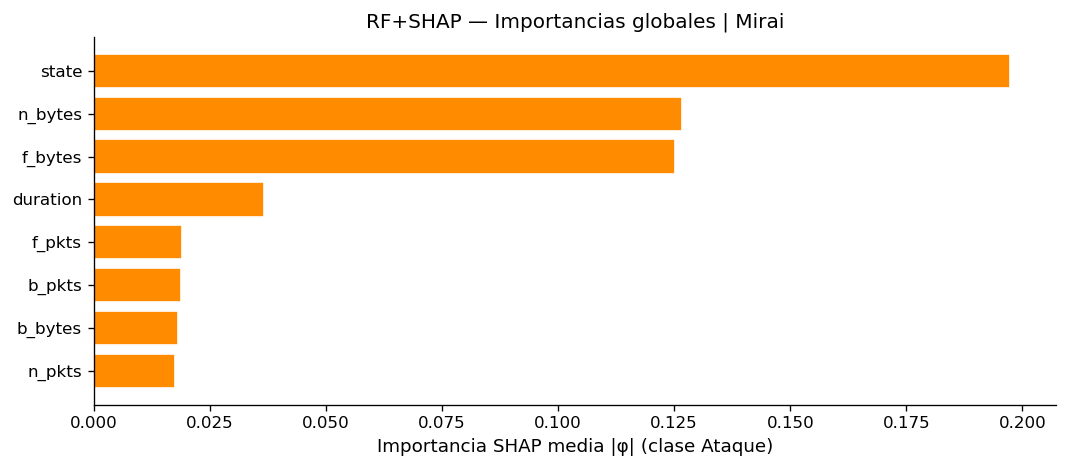

Figura guardada: rfshap_mirai_importancias_globales.png


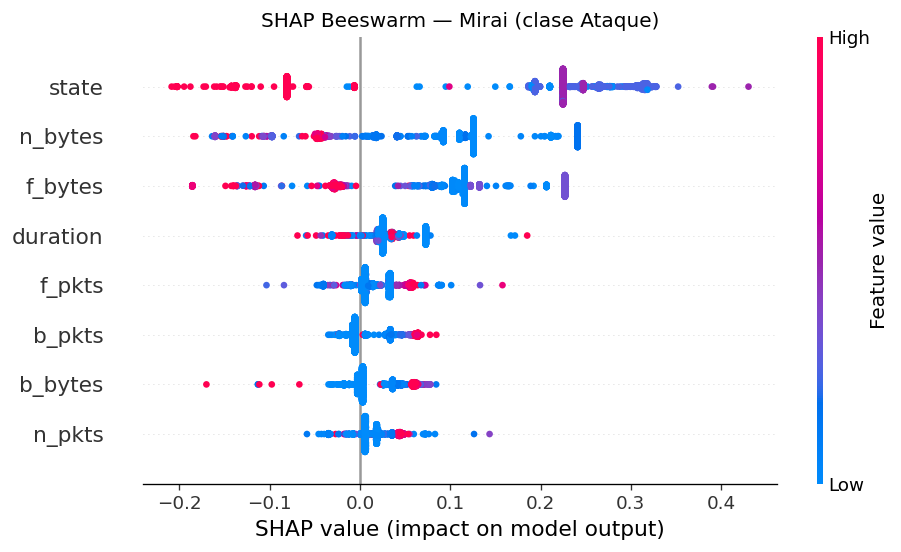

Figura guardada: rfshap_mirai_beeswarm.png

Explicación local — muestra de ataque (Mirai)
  Etiqueta real : Ataque
  Predicción RF : Ataque

Top contribuciones SHAP locales (clase Ataque):
 feature  shap_value  feature_val
   state    0.193812     0.500000
 f_bytes    0.102635     0.000001
 n_bytes    0.092315     0.000002
 b_bytes    0.036147     0.000001
  b_pkts    0.033552     0.000028
duration    0.020656     0.000000
  n_pkts    0.019494     0.000021
  f_pkts    0.001673     0.000000


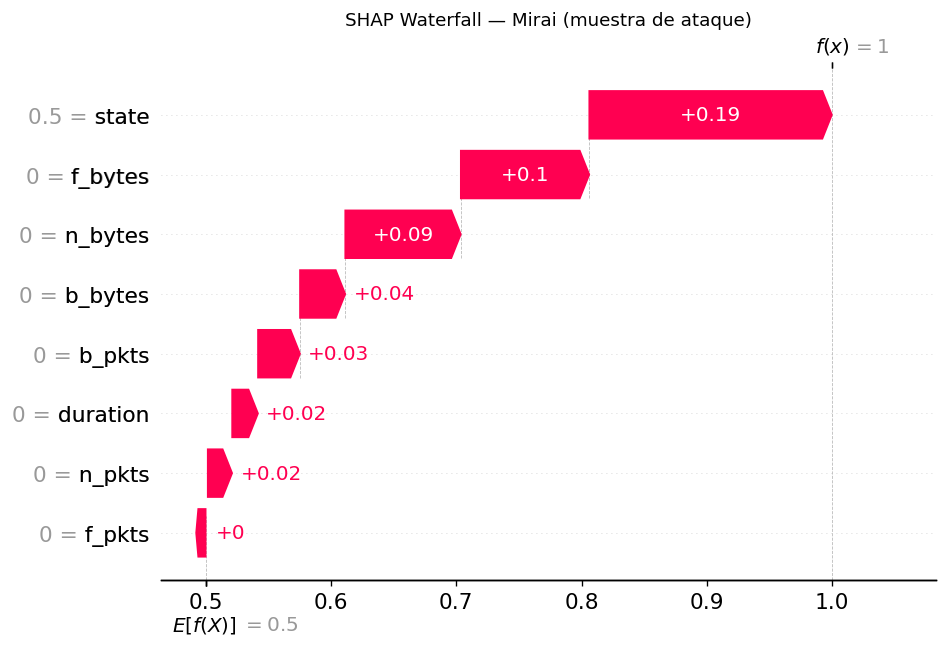

Figura guardada: rfshap_mirai_waterfall_local.png


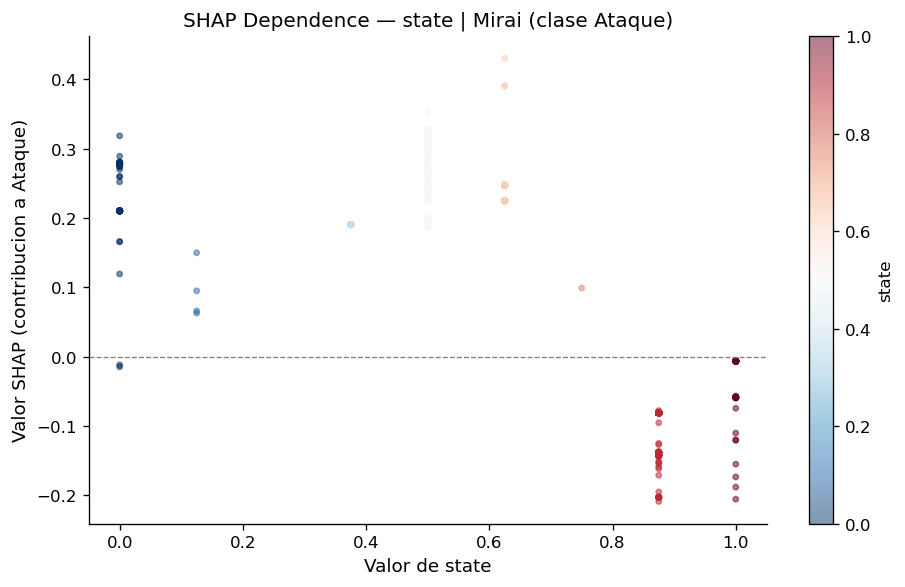

Figura guardada: rfshap_mirai_dependence_state.png


In [7]:
# SHAP: binario (0=Normal, 1=Ataque), get_shap_for_class(idx=1) extrae la contribucion hacia Ataque

if MIRAI_DISPONIBLE:
    print('Calculando valores SHAP para Mirai (puede tardar ~60s)...')

    explainer_mirai = shap.TreeExplainer(rf_mirai)

    np.random.seed(RANDOM_SEED)
    idx_sample_mirai = np.random.choice(
        len(X_te_mirai), size=min(2000, len(X_te_mirai)), replace=False
    )
    X_sample_mirai = X_te_mirai[idx_sample_mirai]
    y_sample_mirai = y_te_mirai[idx_sample_mirai]

    shap_raw_mirai = explainer_mirai.shap_values(X_sample_mirai)
    formato_mirai  = 'lista' if isinstance(shap_raw_mirai, list) else f'array 3D {shap_raw_mirai.shape}'
    print(f'Valores SHAP calculados. Formato: {formato_mirai}')

    # Importancias globales (|SHAP| clase Ataque)
    # Para binario usamos la clase 1 (Ataque) — es la clase de interés en IDS
    idx_ataque = list(rf_mirai.classes_).index(1)
    shap_ataque_mirai   = get_shap_for_class(shap_raw_mirai, idx_ataque)  # (n, 9)
    importancias_mirai  = np.abs(shap_ataque_mirai).mean(axis=0)
    idx_sorted_mirai    = np.argsort(importancias_mirai)[::-1]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(
        [FEATURE_COLS_MIRAI[i] for i in idx_sorted_mirai][::-1],
        [importancias_mirai[i] for i in idx_sorted_mirai][::-1],
        color='darkorange', edgecolor='white'
    )
    ax.set_xlabel('Importancia SHAP media |φ| (clase Ataque)', fontsize=11)
    ax.set_title('RF+SHAP — Importancias globales | Mirai', fontsize=12)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('rfshap_mirai_importancias_globales.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: rfshap_mirai_importancias_globales.png')

    # Beeswarm — clase Ataque
    shap.summary_plot(
        shap_ataque_mirai,
        X_sample_mirai,
        feature_names = FEATURE_COLS_MIRAI,
        show          = False
    )
    plt.title('SHAP Beeswarm — Mirai (clase Ataque)', fontsize=12)
    plt.tight_layout()
    plt.savefig('rfshap_mirai_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: rfshap_mirai_beeswarm.png')

    # Waterfall local — primera muestra de ataque
    idx_ataque_muestra = np.where(y_sample_mirai == 1)[0][0]
    pred_local   = y_pred_mirai[idx_sample_mirai[idx_ataque_muestra]]
    contrib_mirai = shap_ataque_mirai[idx_ataque_muestra]

    print(f'\nExplicación local — muestra de ataque (Mirai)')
    print(f'  Etiqueta real : Ataque')
    print(f'  Predicción RF : {CLASES_MIRAI[pred_local]}')

    contrib_df_mirai = pd.DataFrame({
        'feature'    : FEATURE_COLS_MIRAI,
        'shap_value' : contrib_mirai,
        'feature_val': X_sample_mirai[idx_ataque_muestra]
    }).sort_values('shap_value', key=abs, ascending=False)

    print('\nTop contribuciones SHAP locales (clase Ataque):')
    print(contrib_df_mirai.to_string(index=False))

    expected_val_mirai = explainer_mirai.expected_value
    base_val_mirai = (
        expected_val_mirai[idx_ataque]
        if hasattr(expected_val_mirai, '__len__')
        else expected_val_mirai
    )
    explanation_local_mirai = shap.Explanation(
        values        = contrib_mirai,
        base_values   = base_val_mirai,
        data          = X_sample_mirai[idx_ataque_muestra],
        feature_names = FEATURE_COLS_MIRAI
    )
    shap.waterfall_plot(explanation_local_mirai, show=False)
    plt.title('SHAP Waterfall — Mirai (muestra de ataque)', fontsize=11)
    plt.tight_layout()
    plt.savefig('rfshap_mirai_waterfall_local.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: rfshap_mirai_waterfall_local.png')

    # Dependence plot — feature mas importante (clase Ataque)
    top_feat_idx_mirai  = idx_sorted_mirai[0]
    top_feat_name_mirai = FEATURE_COLS_MIRAI[top_feat_idx_mirai]

    fig, ax = plt.subplots(figsize=(8, 5))
    sc = ax.scatter(
        X_sample_mirai[:, top_feat_idx_mirai],
        shap_ataque_mirai[:, top_feat_idx_mirai],
        c=X_sample_mirai[:, top_feat_idx_mirai],
        cmap='RdBu_r', alpha=0.5, s=10, rasterized=True
    )
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(f'Valor de {top_feat_name_mirai}', fontsize=11)
    ax.set_ylabel('Valor SHAP (contribucion a Ataque)', fontsize=11)
    ax.set_title(f'SHAP Dependence — {top_feat_name_mirai} | Mirai (clase Ataque)', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.colorbar(sc, ax=ax, label=top_feat_name_mirai)
    plt.tight_layout()
    plt.savefig(f'rfshap_mirai_dependence_{top_feat_name_mirai}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: rfshap_mirai_dependence_{top_feat_name_mirai}.png')
else:
    print('Mirai no disponible — omitiendo SHAP.')


---
## DATASET 3 — DS2OS


In [8]:
# mismo preprocesado que CLASIFICADORES_DS2OS.ipynb y EBM.ipynb: NaN->Malicious, limpiar value, quitar timestamp, 8 clases, LabelEncoder, split + MinMaxScaler

CLASS_MAP_DS2OS = {
    'normal'                        : 'Normal',
    'anomalous(DoSattack)'          : 'DoS',
    'anomalous(scan)'               : 'Scan',
    'anomalous(malitiousControl)'   : 'MaliciousControl',
    'anomalous(malitiousOperation)' : 'MaliciousOperation',
    'anomalous(spying)'             : 'Spying',
    'anomalous(dataProbing)'        : 'DataProbing',
    'anomalous(wrongSetUp)'         : 'WrongSetUp',
}
CLASS_TO_INT_DS2OS = {v: i for i, v in enumerate(CLASS_MAP_DS2OS.values())}
INT_TO_CLASS_DS2OS = {v: k for k, v in CLASS_TO_INT_DS2OS.items()}

CAT_COLS_DS2OS = [
    'sourceID', 'sourceAddress', 'sourceType', 'sourceLocation',
    'destinationServiceAddress', 'destinationServiceType',
    'destinationLocation', 'accessedNodeAddress', 'accessedNodeType', 'operation',
]
FEAT_DS2OS = CAT_COLS_DS2OS + ['value']  # 11 features

SEARCH_PATHS_DS2OS = [
    Path("DS2OS.csv"),
    Path.home() / "Downloads" / "DS2OS.csv",
    (Path.home() / ".cache" / "kagglehub" / "datasets" / "libamariyam" / "ds2os-dataset" / "versions" / "1" / "DS2OS.csv"),
]

try:
    ruta_ds2os = next((p for p in SEARCH_PATHS_DS2OS if p.exists()), None)
    if ruta_ds2os is None:
        raise FileNotFoundError("No se encontró DS2OS.csv")

    print(f'Cargando DS2OS desde: {ruta_ds2os}')
    df_ds2os = pd.read_csv(ruta_ds2os)

    # Paso 1 — NaN en accessedNodeType
    df_ds2os['accessedNodeType'] = df_ds2os['accessedNodeType'].fillna('Malicious')

    # Paso 2 — Limpiar columna value
    df_ds2os['value'] = df_ds2os['value'].replace(
        {'False': 0, 'True': 1, 'Twenty': 20, 'none': 0}
    )
    df_ds2os['value'] = pd.to_numeric(df_ds2os['value'], errors='coerce').fillna(0)

    # Paso 3 — Eliminar timestamp
    df_ds2os = df_ds2os.drop(columns=['timestamp'])

    # Paso 4 — Codificar etiquetas
    df_ds2os['y'] = df_ds2os['normality'].map(CLASS_MAP_DS2OS).map(CLASS_TO_INT_DS2OS).astype(np.int8)
    df_ds2os = df_ds2os.drop(columns=['normality'])

    # Paso 5 — Label Encoding de categóricas
    for col in CAT_COLS_DS2OS:
        df_ds2os[col] = LabelEncoder().fit_transform(df_ds2os[col].astype(str))

    # Paso 6 — Split y escalado
    X_ds2os    = df_ds2os[FEAT_DS2OS].values
    y_ds2os    = df_ds2os['y'].values

    X_tr_ds2os, X_te_ds2os, y_tr_ds2os, y_te_ds2os = train_test_split(
        X_ds2os, y_ds2os,
        test_size    = 0.20,
        random_state = RANDOM_SEED,
        stratify     = y_ds2os
    )

    scaler_ds2os = MinMaxScaler()
    X_tr_ds2os   = scaler_ds2os.fit_transform(X_tr_ds2os)
    X_te_ds2os   = scaler_ds2os.transform(X_te_ds2os)

    CLASES_DS2OS = [INT_TO_CLASS_DS2OS[i] for i in sorted(INT_TO_CLASS_DS2OS.keys())]

    print(f'DS2OS cargado: {len(df_ds2os):,} instancias')
    print(f'Train: {len(X_tr_ds2os):,} | Test: {len(X_te_ds2os):,}')
    print(f'Features: {FEAT_DS2OS}')
    DS2OS_DISPONIBLE = True

except FileNotFoundError as e:
    print(f'AVISO: {e}')
    DS2OS_DISPONIBLE = False


Cargando DS2OS desde: C:\Users\user\.cache\kagglehub\datasets\libamariyam\ds2os-dataset\versions\1\DS2OS.csv


DS2OS cargado: 357,952 instancias
Train: 286,361 | Test: 71,591
Features: ['sourceID', 'sourceAddress', 'sourceType', 'sourceLocation', 'destinationServiceAddress', 'destinationServiceType', 'destinationLocation', 'accessedNodeAddress', 'accessedNodeType', 'operation', 'value']


In [9]:
# entrenamiento RF y métricas
if DS2OS_DISPONIBLE:
    rf_ds2os = RandomForestClassifier(**RF_PARAMS)

    print('Entrenando Random Forest en DS2OS (puede tardar ~2 min)...')
    rf_ds2os.fit(X_tr_ds2os, y_tr_ds2os)
    print('Entrenamiento completado.')

    y_pred_ds2os  = rf_ds2os.predict(X_te_ds2os)
    y_proba_ds2os = rf_ds2os.predict_proba(X_te_ds2os)

    res_ds2os = evaluar_modelo(
        y_te_ds2os, y_pred_ds2os, y_proba_ds2os,
        nombre_dataset = 'DS2OS',
        nombres_clases = CLASES_DS2OS
    )
else:
    print('DS2OS no disponible — omitiendo entrenamiento.')


Entrenando Random Forest en DS2OS (puede tardar ~2 min)...


Entrenamiento completado.


  RF+SHAP — DS2OS                                   
  Accuracy   : 0.9939
  Precision  : 0.9659  (macro)
  Recall     : 0.9992  (macro)
  F1-Score   : 0.9799  (macro)
  AUC-ROC    : 0.9998
------------------------------------------------------------
                    precision    recall  f1-score   support

            Normal       1.00      0.99      1.00     69588
               DoS       0.73      1.00      0.84      1156
              Scan       1.00      1.00      1.00       310
  MaliciousControl       1.00      1.00      1.00       178
MaliciousOperation       1.00      1.00      1.00       161
            Spying       1.00      1.00      1.00       106
       DataProbing       1.00      1.00      1.00        68
        WrongSetUp       1.00      1.00      1.00        24

          accuracy                           0.99     71591
         macro avg       0.97      1.00      0.98     71591
      weighted avg       1.00      0.99      0.99     71591



Calculando SHAP para DS2OS — importancias globales (1000 muestras)...


Valores SHAP calculados. Formato: array 3D (1000, 11, 8)


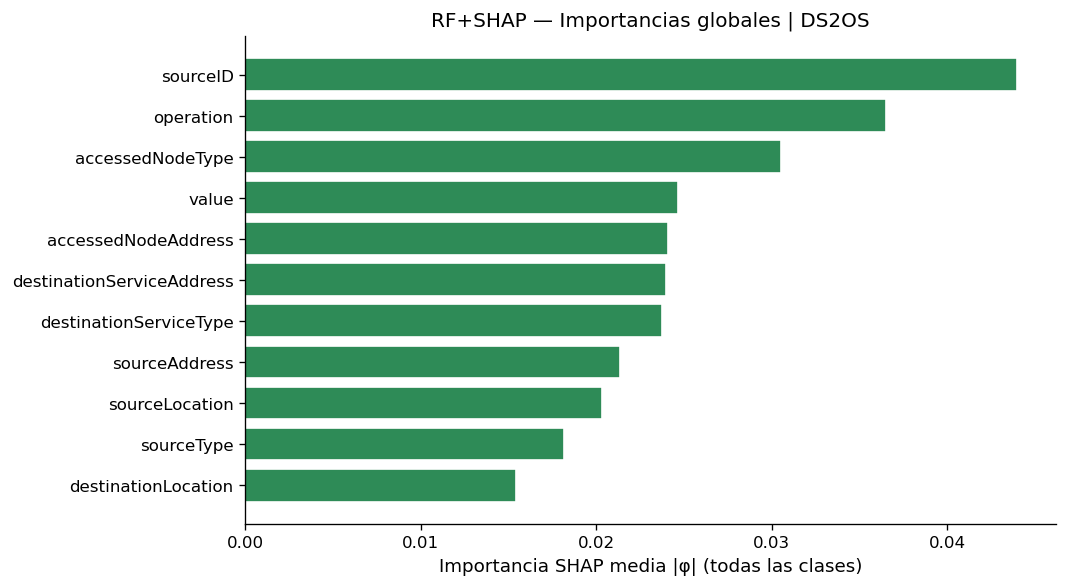

Figura guardada: rfshap_ds2os_importancias_globales.png

Calculando SHAP para beeswarm DoS (submuestra balanceada)...
  Submuestra balanceada: 1156 DoS + 1156 Normal = 2312 muestras


  Valores SHAP calculados. Formato: array 3D (2312, 11, 8)


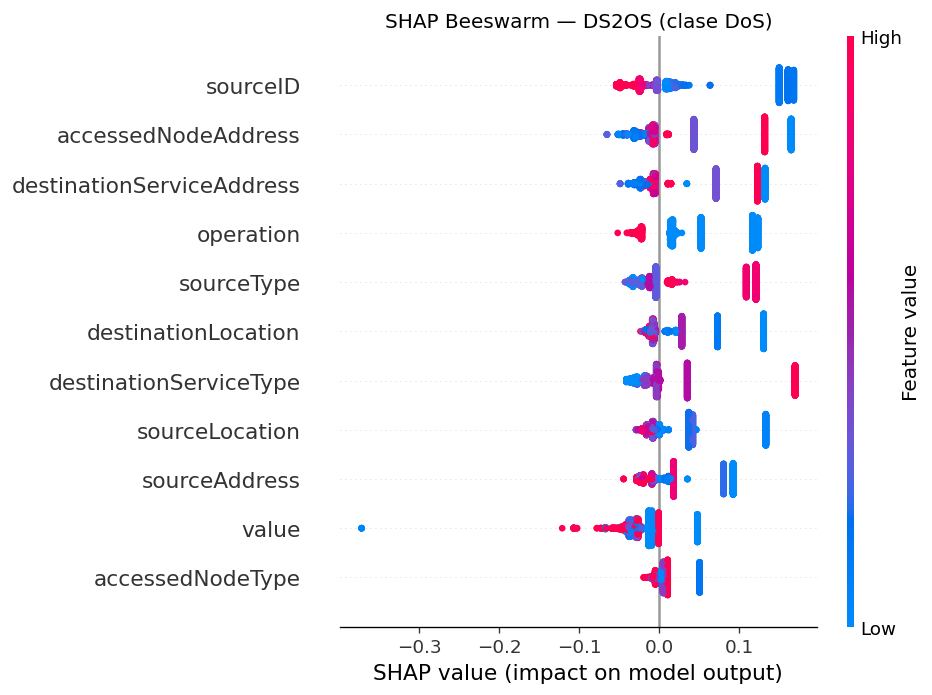

Figura guardada: rfshap_ds2os_beeswarm_dos.png


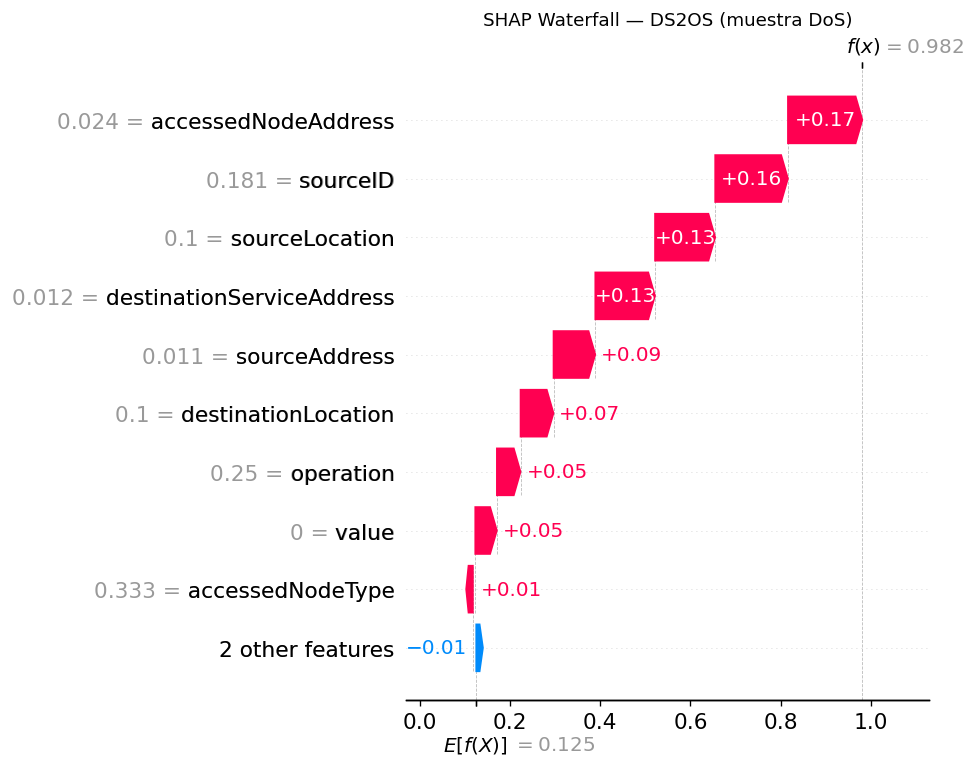

Figura guardada: rfshap_ds2os_waterfall_local.png


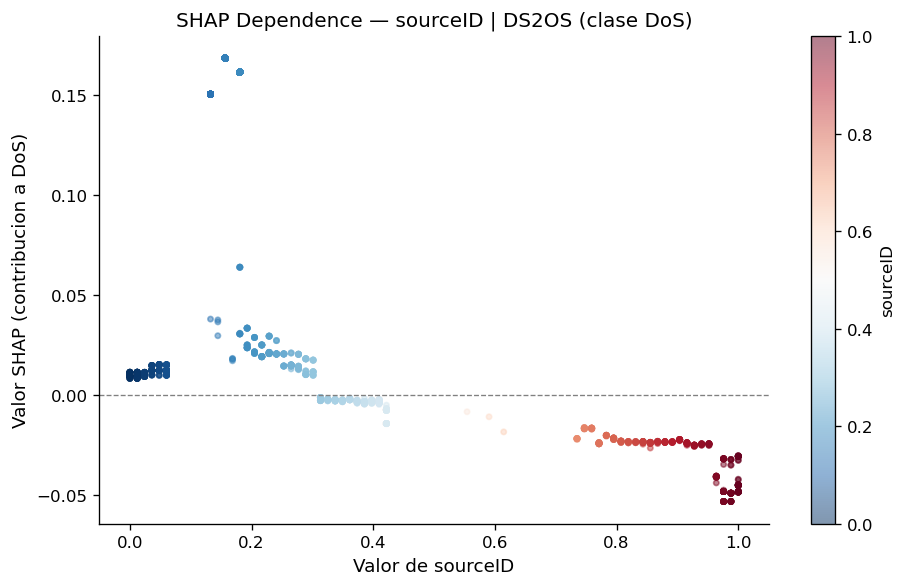

Figura guardada: rfshap_ds2os_dependence_sourceID.png


In [10]:
# SHAP

if DS2OS_DISPONIBLE:
    explainer_ds2os = shap.TreeExplainer(rf_ds2os)

    # Submuestra aleatoria para importancias globales
    print('Calculando SHAP para DS2OS — importancias globales (1000 muestras)...')
    np.random.seed(RANDOM_SEED)
    idx_sample_ds2os = np.random.choice(
        len(X_te_ds2os), size=min(1000, len(X_te_ds2os)), replace=False
    )
    X_sample_ds2os = X_te_ds2os[idx_sample_ds2os]

    shap_raw_ds2os = explainer_ds2os.shap_values(X_sample_ds2os)
    formato_ds2os = 'lista' if isinstance(shap_raw_ds2os, list) else f'array 3D {shap_raw_ds2os.shape}'
    print(f'Valores SHAP calculados. Formato: {formato_ds2os}')

    # Importancias globales (|SHAP| medio sobre todas las clases)
    shap_abs_mean_ds2os = get_all_classes_abs_mean(shap_raw_ds2os)
    importancias_ds2os  = shap_abs_mean_ds2os.mean(axis=0)
    idx_sorted_ds2os    = np.argsort(importancias_ds2os)[::-1]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(
        [FEAT_DS2OS[i] for i in idx_sorted_ds2os][::-1],
        [importancias_ds2os[i] for i in idx_sorted_ds2os][::-1],
        color='seagreen', edgecolor='white'
    )
    ax.set_xlabel('Importancia SHAP media |φ| (todas las clases)', fontsize=11)
    ax.set_title('RF+SHAP — Importancias globales | DS2OS', fontsize=12)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('rfshap_ds2os_importancias_globales.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: rfshap_ds2os_importancias_globales.png')

    # Beeswarm DoS — submuestra BALANCEADA
    # Todas las muestras DoS del test + mismo número de Normales.
    # Evita que el 98.4% de Normales comprima todos los SHAP hacia 0.
    print('\nCalculando SHAP para beeswarm DoS (submuestra balanceada)...')
    idx_dos_te   = np.where(y_te_ds2os == CLASS_TO_INT_DS2OS['DoS'])[0]
    idx_norm_te  = np.where(y_te_ds2os == CLASS_TO_INT_DS2OS['Normal'])[0]
    np.random.seed(RANDOM_SEED)
    idx_norm_bal = np.random.choice(idx_norm_te, size=len(idx_dos_te), replace=False)
    idx_bal      = np.sort(np.concatenate([idx_dos_te, idx_norm_bal]))

    X_bal_ds2os = X_te_ds2os[idx_bal]
    print(f'  Submuestra balanceada: {len(idx_dos_te)} DoS + {len(idx_norm_bal)} Normal = {len(idx_bal)} muestras')

    shap_raw_bal_ds2os = explainer_ds2os.shap_values(X_bal_ds2os)
    formato_bal = 'lista' if isinstance(shap_raw_bal_ds2os, list) else f'array 3D {shap_raw_bal_ds2os.shape}'
    print(f'  Valores SHAP calculados. Formato: {formato_bal}')

    idx_dos_cls = list(rf_ds2os.classes_).index(CLASS_TO_INT_DS2OS['DoS'])
    shap_dos_ds2os = get_shap_for_class(shap_raw_bal_ds2os, idx_dos_cls)

    shap.summary_plot(
        shap_dos_ds2os,
        X_bal_ds2os,
        feature_names = FEAT_DS2OS,
        show          = False
    )
    plt.title('SHAP Beeswarm — DS2OS (clase DoS)', fontsize=12)
    plt.tight_layout()
    plt.savefig('rfshap_ds2os_beeswarm_dos.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: rfshap_ds2os_beeswarm_dos.png')

    # Waterfall local — primera muestra DoS (submuestra balanceada)
    y_bal_ds2os    = y_te_ds2os[idx_bal]
    idx_dos_in_bal = np.where(y_bal_ds2os == CLASS_TO_INT_DS2OS['DoS'])[0][0]
    contrib_dos_single = shap_dos_ds2os[idx_dos_in_bal]
    x_dos_single       = X_bal_ds2os[idx_dos_in_bal]

    expected_val_ds2os = explainer_ds2os.expected_value
    base_val_dos = (expected_val_ds2os[idx_dos_cls]
                    if hasattr(expected_val_ds2os, '__len__')
                    else expected_val_ds2os)

    explanation_dos_single = shap.Explanation(
        values        = contrib_dos_single,
        base_values   = base_val_dos,
        data          = x_dos_single,
        feature_names = FEAT_DS2OS
    )
    shap.waterfall_plot(explanation_dos_single, show=False)
    plt.title('SHAP Waterfall — DS2OS (muestra DoS)', fontsize=11)
    plt.tight_layout()
    plt.savefig('rfshap_ds2os_waterfall_local.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: rfshap_ds2os_waterfall_local.png')

    # Dependence plot — feature mas importante (clase DoS)
    top_feat_idx_ds2os  = idx_sorted_ds2os[0]
    top_feat_name_ds2os = FEAT_DS2OS[top_feat_idx_ds2os]

    fig, ax = plt.subplots(figsize=(8, 5))
    sc = ax.scatter(
        X_bal_ds2os[:, top_feat_idx_ds2os],
        shap_dos_ds2os[:, top_feat_idx_ds2os],
        c=X_bal_ds2os[:, top_feat_idx_ds2os],
        cmap='RdBu_r', alpha=0.5, s=10, rasterized=True
    )
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(f'Valor de {top_feat_name_ds2os}', fontsize=11)
    ax.set_ylabel('Valor SHAP (contribucion a DoS)', fontsize=11)
    ax.set_title(f'SHAP Dependence — {top_feat_name_ds2os} | DS2OS (clase DoS)', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.colorbar(sc, ax=ax, label=top_feat_name_ds2os)
    plt.tight_layout()
    plt.savefig(f'rfshap_ds2os_dependence_{top_feat_name_ds2os}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: rfshap_ds2os_dependence_{top_feat_name_ds2os}.png')
else:
    print('DS2OS no disponible — omitiendo SHAP.')


---
## Comparativa final — RF+SHAP vs EBM

## Permutation Importance (PI)

              Permutation Importance - RF - NSL-KDD               


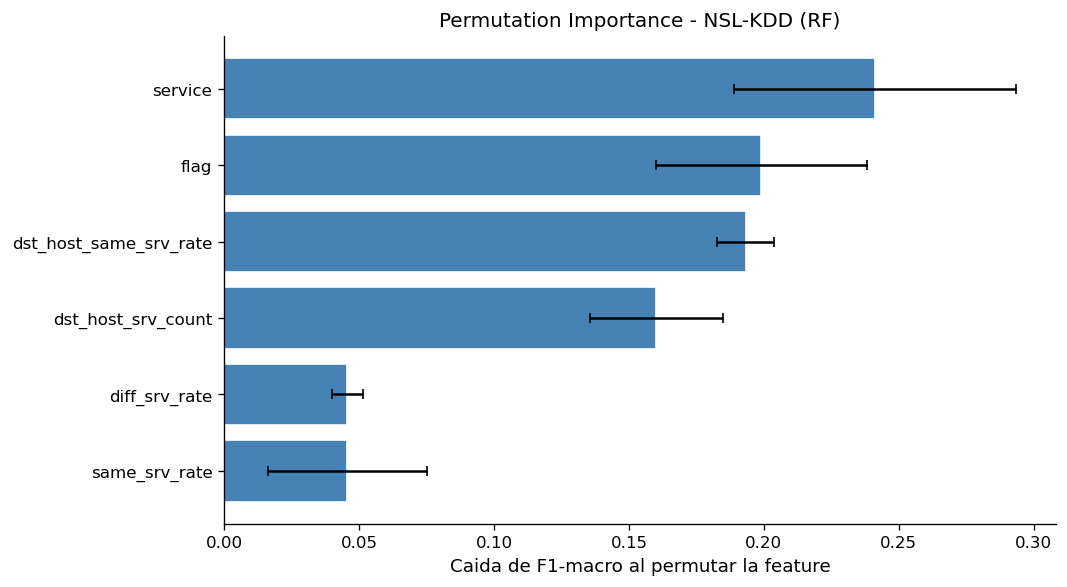

Figura guardada: pi_rf_nslkdd.png

Feature                     PI media   +/-std  rank PI  rank SHAP
------------------------------------------------------------------
service                       0.2413   0.0523        1          1
flag                          0.1991   0.0391        2          3
dst_host_same_srv_rate        0.1932   0.0105        3          5
dst_host_srv_count            0.1602   0.0247        4          2
diff_srv_rate                 0.0457   0.0059        5          6
same_srv_rate                 0.0457   0.0294        6          4
               Permutation Importance - RF - Mirai                


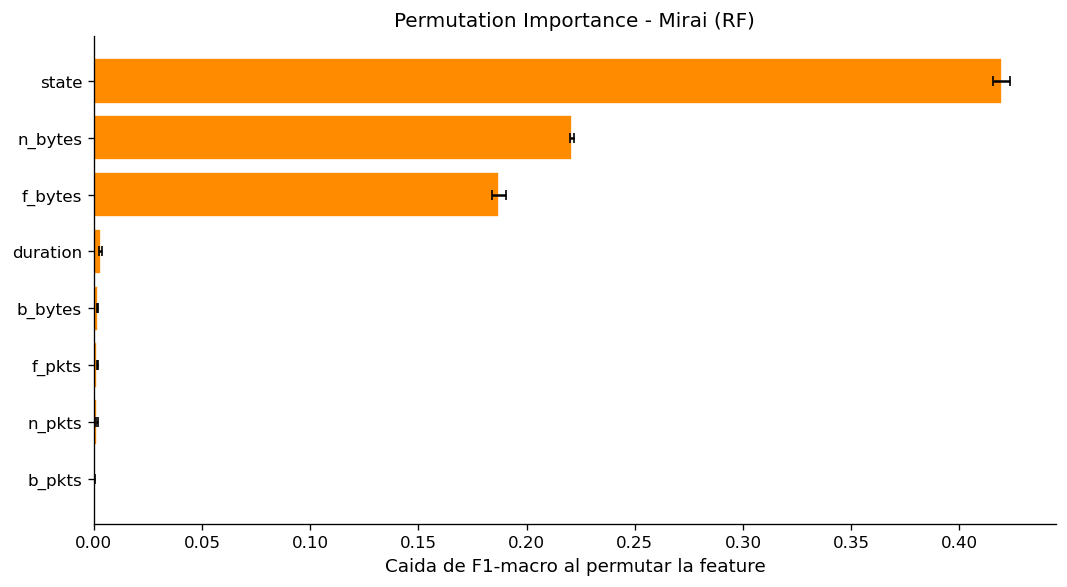

Figura guardada: pi_rf_mirai.png

Feature                     PI media   +/-std  rank PI  rank SHAP
------------------------------------------------------------------
state                         0.4195   0.0039        1          1
n_bytes                       0.2208   0.0010        2          2
f_bytes                       0.1872   0.0031        3          3
duration                      0.0031   0.0008        4          4
b_bytes                       0.0018   0.0004        5          7
f_pkts                        0.0017   0.0004        6          5
n_pkts                        0.0013   0.0005        7          8
b_pkts                        0.0005   0.0003        8          6
               Permutation Importance - RF - DS2OS                


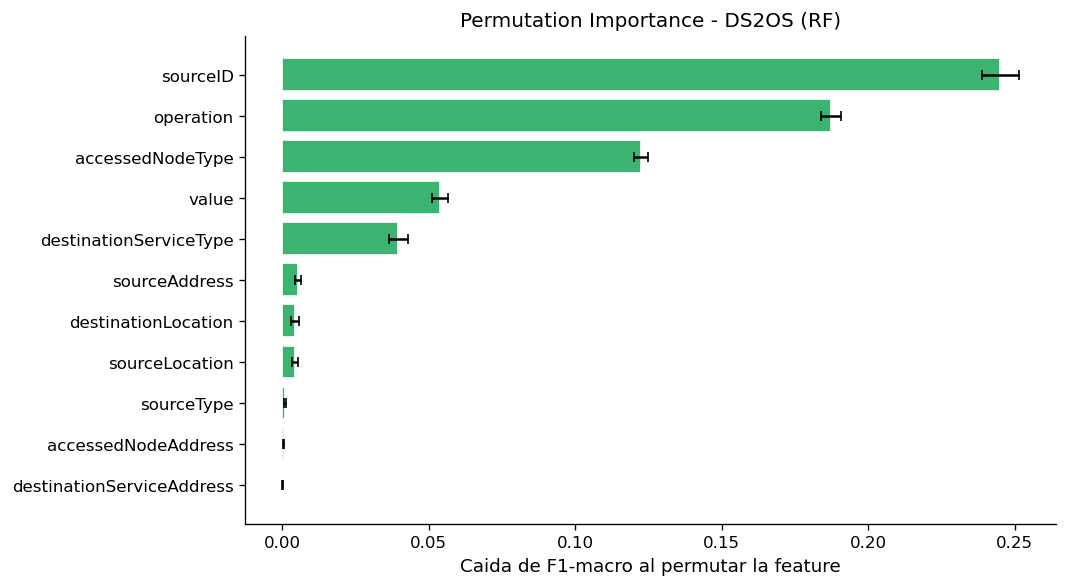

Figura guardada: pi_rf_ds2os.png

Feature                     PI media   +/-std  rank PI  rank SHAP
------------------------------------------------------------------
sourceID                      0.2452   0.0064        1          1
operation                     0.1873   0.0034        2          2
accessedNodeType              0.1224   0.0024        3          3
value                         0.0537   0.0027        4          4
destinationServiceType        0.0396   0.0031        5          7
sourceAddress                 0.0053   0.0010        6          8
destinationLocation           0.0043   0.0014        7         11
sourceLocation                0.0043   0.0009        8          9
sourceType                    0.0009   0.0004        9         10
accessedNodeAddress           0.0004   0.0002       10          5
destinationServiceAddress     0.0000   0.0001       11          6


In [11]:
# permutation importance (RF, 3 datasets): mide cuanto cae el F1-macro al barajar cada feature sobre el RF ya entrenado

from sklearn.inspection import permutation_importance

def pi_rf(modelo, X_te, y_te, feat_names, shap_imp, nombre_ds, color, fname):
    print('=' * 66)
    print(f' Permutation Importance - RF - {nombre_ds} '.center(66))
    print('=' * 66)

    pi = permutation_importance(
        modelo, X_te, y_te,
        n_repeats=10, scoring='f1_macro', random_state=RANDOM_SEED, n_jobs=-1,
    )
    orden = np.argsort(pi.importances_mean)[::-1]

    # Bar chart con barras de error (std de los 10 repeats)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(
        [feat_names[i] for i in orden][::-1],
        [pi.importances_mean[i] for i in orden][::-1],
        xerr=[pi.importances_std[i] for i in orden][::-1],
        color=color, edgecolor='white', capsize=3,
    )
    ax.set_xlabel('Caida de F1-macro al permutar la feature', fontsize=11)
    ax.set_title(f'Permutation Importance - {nombre_ds} (RF)', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname}')

    # Tabla de consistencia: ranking PI vs ranking SHAP
    orden_shap = np.argsort(shap_imp)[::-1]
    rank_pi    = {feat_names[i]: r for r, i in enumerate(orden, 1)}
    rank_shap  = {feat_names[i]: r for r, i in enumerate(orden_shap, 1)}

    print(f'\n{"Feature":<26}{"PI media":>10}{"+/-std":>9}{"rank PI":>9}{"rank SHAP":>11}')
    print('-' * 66)
    for i in orden:
        f = feat_names[i]
        print(f'{f:<26}{pi.importances_mean[i]:>10.4f}{pi.importances_std[i]:>9.4f}'
              f'{rank_pi[f]:>9}{rank_shap[f]:>11}')
    return pi

# NSL-KDD
pi_rf_nsl = pi_rf(rf_nsl, X_te_nsl, y_te_nsl, SELECTED_FEATURES_NSL,
                  importancias_nsl, 'NSL-KDD', 'steelblue', 'pi_rf_nslkdd.png')

# Mirai
if MIRAI_DISPONIBLE:
    pi_rf_mirai = pi_rf(rf_mirai, X_te_mirai, y_te_mirai, FEATURE_COLS_MIRAI,
                        importancias_mirai, 'Mirai', 'darkorange', 'pi_rf_mirai.png')

# DS2OS
if DS2OS_DISPONIBLE:
    pi_rf_ds2os = pi_rf(rf_ds2os, X_te_ds2os, y_te_ds2os, FEAT_DS2OS,
                        importancias_ds2os, 'DS2OS', 'mediumseagreen', 'pi_rf_ds2os.png')


### Export de rankings (SHAP + PI-RF) a JSON

In [12]:
# EXPORT - rankings XAI del RF (SHAP + PI-RF) a JSON
import json
from pathlib import Path
RESULTS_DIR = Path('C:/Users/user/TFM')

export_rf = {}
def _add_rf(nombre, feat_names, shap_imp, pi):
    export_rf[nombre] = {
        f: {'shap': float(shap_imp[i]),
            'pi_rf_mean': float(pi.importances_mean[i]),
            'pi_rf_std':  float(pi.importances_std[i])}
        for i, f in enumerate(feat_names)
    }

_add_rf('NSL-KDD', SELECTED_FEATURES_NSL, importancias_nsl, pi_rf_nsl)
if MIRAI_DISPONIBLE:
    _add_rf('Mirai', FEATURE_COLS_MIRAI, importancias_mirai, pi_rf_mirai)
if DS2OS_DISPONIBLE:
    _add_rf('DS2OS', FEAT_DS2OS, importancias_ds2os, pi_rf_ds2os)

with open(RESULTS_DIR / 'xai_rankings_rf_sinleak.json', 'w', encoding='utf-8') as fh:
    json.dump(export_rf, fh, indent=2)
print('Guardado:', RESULTS_DIR / 'xai_rankings_rf_sinleak.json')


Guardado: C:\Users\user\TFM\xai_rankings_rf_sinleak.json
